# Survival analysis

As with logistic regression, requires full UKB phenotype data

In [9]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import matplotlib
matplotlib.rc_file_defaults()
matplotlib.rcParams['font.family'] = 'Lato'
matplotlib.rcParams['pdf.fonttype'] = 42

import lifelines
from lifelines import CoxPHFitter

print('matplotlib', matplotlib.__version__)
print('pandas', pd.__version__)
print('numpy', np.__version__)
print('lifelines', lifelines.__version__)

matplotlib 3.8.2
pandas 2.1.3
numpy 1.26.2
lifelines 0.28.0


In [2]:
# phenotype file
biobank_pheno_cancer_smoking_BMI = pd.read_csv('data/biobank_pheno_cancer_smoking_BMI_select_columns_updated_2025_reclassified.tsv', sep='\t')

# ancestry file
ukb_ancestry = pd.read_csv('data/ukb_iadmix_ancestry_props.csv').rename(columns={'ukbid':'ID_v0'})

# TP53 variants
ukb_tp53_all = pd.read_csv('data/ukb_tp53_all_variants_unredacted.tsv', sep='\t')

### Set up Cox regression dataset

In [3]:
## start creating dataset for cox regression
# eliminate anyone who has retrospective cancer (n = 459404)
data_cox = biobank_pheno_cancer_smoking_BMI[biobank_pheno_cancer_smoking_BMI.cancer_status != 'retrospective'].reset_index(drop=True)
print(len(data_cox))
# remove people with cancer, self-reported with age/date unknown (-> n = 459330)
data_cox = data_cox[~(data_cox['self.cancer.age1_v0'] == -1)].reset_index(drop=True)
print(len(data_cox))

# filter the less useful columns
data_cox = data_cox[['ID_v0', 'Sex_v0', 'Ever.smoked_v0', 'Smoking_status', 'Smoking_level', 'pack_years', 'Body.mass.index..BMI._v0', 'Age.when.attended.assessment.centre_v0', 'Date.of.attending.assessment.centre_v0', 'first.diagnosed.cancer.age1', 'first.diagnosed.cancer.date1', 'first.diagnosed.cancer.type1', 'prospective_cancer_site', 'Age.at.death_v0', 'Date.of.death_v0', 'cancer_status']].copy()

#From email from Xin (21/04/23):
#- latest cancer registry linkage is 2022-03-15
#- latest death registry linkage is 2022-12-19

#Makes sense then to use the cancer date as the endpoint of the study. If the patient died (cancer-free) after 15/03/2022, they count as 'alive' for the purposes of this analysis

data_cox['end_date'] = pd.to_datetime('2022-03-15')
data_cox['end_status'] = 'alive'
data_cox['Date.of.attending.assessment.centre_v0'] = pd.to_datetime(data_cox['Date.of.attending.assessment.centre_v0'])
data_cox['first.diagnosed.cancer.date1'] = pd.to_datetime(data_cox['first.diagnosed.cancer.date1'])
data_cox['Date.of.death_v0'] = pd.to_datetime(data_cox['Date.of.death_v0'])

cancer_dict = {'no_cancer':0, 'prospective':1}
data_cox['cancer_01'] = [cancer_dict[x] for x in data_cox['cancer_status']]


for cancer_site_to_analyse in ['respiratory', 'gastrointestinal', 'lymphoma_leukaemia', 'breast', 'other']:
    data_cox[f'{cancer_site_to_analyse}_cancer_01'] = [1 if x == cancer_site_to_analyse else 0 for x in data_cox['prospective_cancer_site']]

# calculate (approximately) age at the end of study
data_cox['end_age'] = data_cox['end_date'] - data_cox['Date.of.attending.assessment.centre_v0']
data_cox['end_age'] = data_cox.end_age.dt.days/365.25 + data_cox['Age.when.attended.assessment.centre_v0'] # convert to integer days, divide to years and add to assessment centre age
data_cox['cause_of_exit'] = 'end_of_study'

#Replace end date for dead participants with age at death and for people who get cancer as the date of diagnosis. There are a few cases where the age is the same for cancer and entry. for these, add 0.1 to the cancer (exit) age

condition = data_cox['Date.of.death_v0'] <= data_cox['end_date']
data_cox.loc[condition, 'end_status'] = 'dead'
data_cox.loc[condition, 'end_age'] = data_cox[condition]['Age.at.death_v0']
data_cox.loc[condition, 'cause_of_exit'] = 'death'

# replace end date for cancer as cancer date
condition = data_cox['first.diagnosed.cancer.date1'] == data_cox['first.diagnosed.cancer.date1']
data_cox.loc[condition, 'end_age'] = data_cox[condition]['first.diagnosed.cancer.age1']
data_cox.loc[condition, 'cause_of_exit'] = 'cancer'

# there are a few cases where the age is the same for cancer and entry. for these, add 0.1 to the cancer (exit) age
condition = data_cox['Age.when.attended.assessment.centre_v0'] == data_cox['end_age']
data_cox.loc[condition, 'end_age'] = data_cox[condition]['end_age'] + 0.1

data_cox = pd.merge(data_cox, ukb_ancestry[['ID_v0', 'iadmix_main_ancestry_v2']], how='left', on='ID_v0')

421856
421847


In [4]:
# pathogenic variants
ukb_tp53_plp = ukb_tp53_all[ukb_tp53_all.Classification_by_multifactorial_model.isin(['Pathogenic', 'Likely_Pathogenic'])].reset_index(drop=True)
ukb_tp53_plp['pathogenic_variant'] = 1

# merge pathogenic carrier info into data_cox
data_cox = pd.merge(data_cox, ukb_tp53_plp[['ID_v0', 'pathogenic_variant']], how='left', on='ID_v0').drop_duplicates('ID_v0')
data_cox['pathogenic_variant'].replace(np.nan, 0., inplace=True)
data_cox['pathogenic_variant'] = data_cox['pathogenic_variant'].astype(int)
print(sum(data_cox['pathogenic_variant']))

# pathogenic variants (continuous VAF model)
data_cox = pd.merge(data_cox, ukb_tp53_plp[['ID_v0', 'VAF']].rename(columns={'VAF':'pathogenic_VAF'}), how='left', on='ID_v0').drop_duplicates('ID_v0')
data_cox['pathogenic_VAF'].replace(np.nan, 0, inplace=True)

# pathogenic varinats: classification
ukb_tp53_plp_likely = ukb_tp53_plp[ukb_tp53_plp.germ_likelihood == 'likely'].reset_index(drop=True)
ukb_tp53_plp_likely['plp_likely_germline'] = 1
data_cox = pd.merge(data_cox, ukb_tp53_plp_likely[['ID_v0', 'plp_likely_germline']], how='left', on='ID_v0').drop_duplicates('ID_v0')
data_cox['plp_likely_germline'].replace(np.nan, 0., inplace=True)
data_cox['plp_likely_germline'] = data_cox['plp_likely_germline'].astype(int)
print(sum(data_cox['plp_likely_germline']), 'likely germline')

# unlikely germline
ukb_tp53_plp_unlikely = ukb_tp53_plp[ukb_tp53_plp.germ_likelihood == 'unlikely'].reset_index(drop=True)
ukb_tp53_plp_unlikely['plp_unlikely_germline'] = 1
data_cox = pd.merge(data_cox, ukb_tp53_plp_unlikely[['ID_v0', 'plp_unlikely_germline']], how='left', on='ID_v0').drop_duplicates('ID_v0')
data_cox['plp_unlikely_germline'].replace(np.nan, 0., inplace=True)
data_cox['plp_unlikely_germline'] = data_cox['plp_unlikely_germline'].astype(int)
print(sum(data_cox['plp_unlikely_germline']), 'likely somatic')

# inconclusive
ukb_tp53_plp_inconclusive = ukb_tp53_plp[ukb_tp53_plp.germ_likelihood == 'inconclusive'].reset_index(drop=True)
ukb_tp53_plp_inconclusive['plp_inconclusive'] = 1
data_cox = pd.merge(data_cox, ukb_tp53_plp_inconclusive[['ID_v0', 'plp_inconclusive']], how='left', on='ID_v0').drop_duplicates('ID_v0')
data_cox['plp_inconclusive'].replace(np.nan, 0., inplace=True)
data_cox['plp_inconclusive'] = data_cox['plp_inconclusive'].astype(int)
print(sum(data_cox['plp_inconclusive']), 'inconclusive')

# ancestry dummy variables
data_cox = pd.get_dummies(data_cox, columns=['iadmix_main_ancestry_v2'])

# smoking dummy variables are done when required

# convert sex into binary male/female column for analysis
data_cox['Sex_male'] = data_cox['Sex_v0'] == 'Male'

# scale bmi data
data_cox['BMI_scaled'] = (data_cox['Body.mass.index..BMI._v0'] - data_cox['Body.mass.index..BMI._v0'].mean()) / data_cox['Body.mass.index..BMI._v0'].std()

# convert smoking data to True/False
data_cox['Ever.smoked_v0'] = data_cox['Ever.smoked_v0'].map({'Yes':True, 'No':False})

262
45 likely germline
189 likely somatic
28 inconclusive


## Models

In [5]:
all_models = {}

In [6]:
def get_results(model):

    df = model.summary[['coef', 'coef lower 95%', 'coef upper 95%']]
    df['lower_error'] = df['coef'] -  df['coef lower 95%']
    df['upper_error'] = df['coef upper 95%'] - df['coef']
    df['p_value'] = model.summary['p']
    return df

For each variant classification, with and without smoking (CFN). Exclude missing smokers in both analyses for consistency.

Without smoking

In [7]:
data_cox_filtered = data_cox[['Age.when.attended.assessment.centre_v0', 'end_age', 'cancer_01', 'Sex_male', 'Smoking_status', 'BMI_scaled',
                              'plp_likely_germline', 'plp_unlikely_germline',
                              'plp_inconclusive',
                              'iadmix_main_ancestry_v2_AFR', 
                              'iadmix_main_ancestry_v2_EAS',
                              'iadmix_main_ancestry_v2_Mixed',
                              'iadmix_main_ancestry_v2_SAS']]


data_cox_filtered = data_cox_filtered[(data_cox_filtered['Smoking_status'] == data_cox_filtered['Smoking_status']) & (data_cox_filtered['BMI_scaled'] == data_cox_filtered['BMI_scaled'])]

# likely germline
print('germline')
data_cox_for_processing = data_cox_filtered[['Age.when.attended.assessment.centre_v0', 'end_age', 'cancer_01', 'Sex_male', 'BMI_scaled', 'plp_likely_germline', 'iadmix_main_ancestry_v2_AFR', 'iadmix_main_ancestry_v2_EAS', 'iadmix_main_ancestry_v2_Mixed', 'iadmix_main_ancestry_v2_SAS']]

all_models[f'NS_germ'] = CoxPHFitter().fit(data_cox_for_processing, duration_col='end_age', event_col='cancer_01', entry_col='Age.when.attended.assessment.centre_v0')

# likely somatic (unlikely_germline)
print('somatic')
data_cox_for_processing = data_cox_filtered[['Age.when.attended.assessment.centre_v0', 'end_age', 'cancer_01', 'Sex_male', 'BMI_scaled', 'plp_unlikely_germline', 'iadmix_main_ancestry_v2_AFR', 'iadmix_main_ancestry_v2_EAS', 'iadmix_main_ancestry_v2_Mixed', 'iadmix_main_ancestry_v2_SAS']]

all_models[f'NS_ungerm'] = CoxPHFitter().fit(data_cox_for_processing, duration_col='end_age', event_col='cancer_01', entry_col='Age.when.attended.assessment.centre_v0')

# inconclusive
print('inconclusive')
data_cox_for_processing = data_cox_filtered[['Age.when.attended.assessment.centre_v0', 'end_age', 'cancer_01', 'Sex_male', 'BMI_scaled', 'plp_inconclusive', 'iadmix_main_ancestry_v2_AFR', 'iadmix_main_ancestry_v2_EAS', 'iadmix_main_ancestry_v2_Mixed', 'iadmix_main_ancestry_v2_SAS']]

all_models[f'NS_inc'] = CoxPHFitter().fit(data_cox_for_processing, duration_col='end_age', event_col='cancer_01', entry_col='Age.when.attended.assessment.centre_v0')


germline
somatic
inconclusive


/Users/hamish/.conda/envs/ALSPAC/lib/python3.10/site-packages/lifelines/utils/__init__.py:1100: ConvergenceWarning: Column(s) ['plp_inconclusive'] have very low variance. This may harm convergence. 1) Are you using formula's? Did you mean to add '-1' to the end. 2) Try dropping this redundant column before fitting if convergence fails.

  warnings.warn(dedent(warning_text), ConvergenceWarning)


With smoking (CFN)

In [8]:
data_cox_filtered = data_cox[['Age.when.attended.assessment.centre_v0', 'end_age', 'cancer_01', 'Sex_male', 'Smoking_status', 'BMI_scaled',
                              'plp_likely_germline', 'plp_unlikely_germline',
                              'plp_inconclusive',
                              'iadmix_main_ancestry_v2_AFR',
                              'iadmix_main_ancestry_v2_EAS',
                              'iadmix_main_ancestry_v2_Mixed',
                              'iadmix_main_ancestry_v2_SAS']]


data_cox_filtered = data_cox_filtered[(data_cox_filtered['Smoking_status'] == data_cox_filtered['Smoking_status']) & (data_cox_filtered['BMI_scaled'] == data_cox_filtered['BMI_scaled'])]

data_cox_filtered = pd.get_dummies(data_cox_filtered, columns=['Smoking_status'])
data_cox_filtered = data_cox_filtered.drop(columns='Smoking_status_Never') # drop this unnecessary column as it is perfectly correlated with 

# likely germline
print('germline')
data_cox_for_processing = data_cox_filtered[['Age.when.attended.assessment.centre_v0', 'end_age', 'cancer_01', 'Sex_male', 'Smoking_status_Ex', 'Smoking_status_Current', 'BMI_scaled', 'plp_likely_germline', 'iadmix_main_ancestry_v2_AFR', 'iadmix_main_ancestry_v2_EAS', 'iadmix_main_ancestry_v2_Mixed', 'iadmix_main_ancestry_v2_SAS']]

all_models[f'CFN_germ'] = CoxPHFitter().fit(data_cox_for_processing, duration_col='end_age', event_col='cancer_01', entry_col='Age.when.attended.assessment.centre_v0')

# likely somatic (unlikely_germline)
print('somatic')
data_cox_for_processing = data_cox_filtered[['Age.when.attended.assessment.centre_v0', 'end_age', 'cancer_01', 'Sex_male', 'Smoking_status_Ex', 'Smoking_status_Current', 'BMI_scaled', 'plp_unlikely_germline', 'iadmix_main_ancestry_v2_AFR', 'iadmix_main_ancestry_v2_EAS', 'iadmix_main_ancestry_v2_Mixed', 'iadmix_main_ancestry_v2_SAS']]

all_models[f'CFN_ungerm'] = CoxPHFitter().fit(data_cox_for_processing, duration_col='end_age', event_col='cancer_01', entry_col='Age.when.attended.assessment.centre_v0')

# inconclusive
print('inconclusive')
data_cox_for_processing = data_cox_filtered[['Age.when.attended.assessment.centre_v0', 'end_age', 'cancer_01', 'Sex_male', 'Smoking_status_Ex', 'Smoking_status_Current', 'BMI_scaled', 'plp_inconclusive', 'iadmix_main_ancestry_v2_AFR', 'iadmix_main_ancestry_v2_EAS', 'iadmix_main_ancestry_v2_Mixed', 'iadmix_main_ancestry_v2_SAS']]

all_models[f'CFN_inc'] = CoxPHFitter().fit(data_cox_for_processing, duration_col='end_age', event_col='cancer_01', entry_col='Age.when.attended.assessment.centre_v0')


germline
somatic
inconclusive


/Users/hamish/.conda/envs/ALSPAC/lib/python3.10/site-packages/lifelines/utils/__init__.py:1100: ConvergenceWarning: Column(s) ['plp_inconclusive'] have very low variance. This may harm convergence. 1) Are you using formula's? Did you mean to add '-1' to the end. 2) Try dropping this redundant column before fitting if convergence fails.

  warnings.warn(dedent(warning_text), ConvergenceWarning)


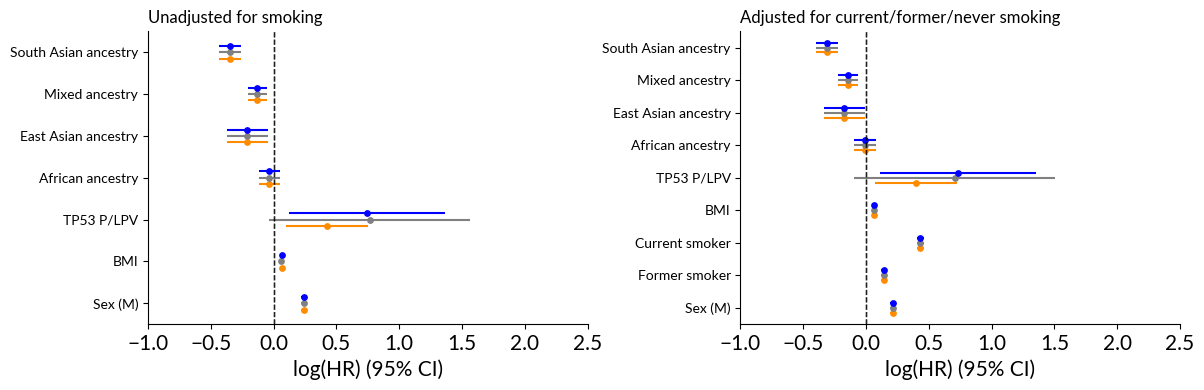

In [9]:
fig, ax = plt.subplots(1, 2, figsize=[12, 4])

pos_list = [-0.15, 0, 0.15]
colour_list = ['darkorange', 'grey', 'blue']
tick_labels_NC = ['South Asian ancestry', 'Mixed ancestry', 'East Asian ancestry', 'African ancestry', 'TP53 P/LPV', 'BMI', 'Sex (M)']
tick_labels_CFN = ['South Asian ancestry', 'Mixed ancestry', 'East Asian ancestry', 'African ancestry', 'TP53 P/LPV', 'BMI','Current smoker', 'Former smoker', 'Sex (M)']

i = 0
for j, model_name in enumerate(['NS_ungerm', 'NS_inc', 'NS_germ']):
    df = get_results(all_models[model_name])
    ax[i].scatter(df.coef, np.arange(len(df))+pos_list[j], marker='o', c=colour_list[j], s=15)
    ax[i].errorbar(df.coef, np.arange(len(df))+pos_list[j], xerr=[df['lower_error'], df['upper_error']], ls='none', zorder=-1, color=colour_list[j], capsize=0)

    ax[i].set_yticks(np.arange(len(df)))
    ax[i].set_yticklabels(tick_labels_NC[::-1], fontsize=10)
    #ax[i].set_yticklabels(tick_names_dict[model_name], fontsize=15)
    ax[i].vlines(0, -0.5, len(df)-0.5, color='k', ls='dashed', lw=1, alpha=0.5)
    ax[i].set_ylim(-0.5, len(df)-0.5)
    ax[i].set_title('Unadjusted for smoking', loc='left')

i = 1
for j, model_name in enumerate(['CFN_ungerm', 'CFN_inc', 'CFN_germ']):
    df = get_results(all_models[model_name])
    ax[i].scatter(df.coef, np.arange(len(df))+pos_list[j], marker='o', c=colour_list[j], s=15)
    ax[i].errorbar(df.coef, np.arange(len(df))+pos_list[j], xerr=[df['lower_error'], df['upper_error']], ls='none', zorder=-1, color=colour_list[j], capsize=0)

    ax[i].set_yticks(np.arange(len(df)))
    ax[i].set_yticklabels(tick_labels_CFN[::-1], fontsize=10)
    #ax[i].set_yticklabels(tick_names_dict[model_name], fontsize=15)
    ax[i].vlines(0, -0.5, len(df)-0.5, color='k', ls='dashed', lw=1, alpha=0.5)
    ax[i].set_ylim(-0.5, len(df)-0.5)
    ax[i].set_title('Adjusted for current/former/never smoking', loc='left')

for i in range(2):
    ax[i].set_xlim(-1, 2.5)
    ax[i].set_xlabel('log(HR) (95% CI)')

plt.tight_layout()


In [10]:
get_results(all_models['CFN_ungerm'])

,coef,coef lower 95%,coef upper 95%,lower_error,upper_error,p_value
covariate,,,,,,
Sex_male,0.211052,0.192756,0.229347,0.018296,0.018296,3.490686e-113
Smoking_status_Ex,0.139821,0.120024,0.159617,0.019796,0.019796,1.400802e-43
Smoking_status_Current,0.430479,0.401944,0.459015,0.028535,0.028535,3.892850e-192
BMI_scaled,0.062120,0.052985,0.071256,0.009135,0.009135,1.596656e-40
plp_unlikely_germline,0.398340,0.071531,0.725149,0.326809,0.326809,1.689639e-02
iadmix_main_ancestry_v2_AFR,-0.006507,-0.092475,0.079461,0.085968,0.085968,8.820724e-01
iadmix_main_ancestry_v2_EAS,-0.172384,-0.337932,-0.006837,0.165548,0.165548,4.126032e-02
iadmix_main_ancestry_v2_Mixed,-0.144233,-0.221020,-0.067447,0.076787,0.076787,2.318436e-04
iadmix_main_ancestry_v2_SAS,-0.307945,-0.396008,-0.219882,0.088063,0.088063,7.193403e-12


### Site-specific analysis

In [11]:
# Fix the C42 problem: some people have the archaic (?) C42 classification that is blood cancer but not specified as such

data_cox.loc[data_cox['first.diagnosed.cancer.type1'] == 'C42', 'other_cancer_01'] = 0
data_cox.loc[data_cox['first.diagnosed.cancer.type1'] == 'C42', 'lymphoma_leukaemia_cancer_01'] = 1

Respiratory

In [12]:
# region respiratory cancer
cancer_site_to_analyse = 'respiratory'

data_cox_filtered = data_cox[
    ['Age.when.attended.assessment.centre_v0', 'end_age', f'{cancer_site_to_analyse}_cancer_01', 'Sex_male', 'Smoking_status', 'BMI_scaled',
     'plp_likely_germline', 'plp_unlikely_germline',
     'plp_inconclusive',
     'iadmix_main_ancestry_v2_AFR',
     'iadmix_main_ancestry_v2_EAS',
     'iadmix_main_ancestry_v2_Mixed',
     'iadmix_main_ancestry_v2_SAS']]


data_cox_filtered = data_cox_filtered[(data_cox_filtered['Smoking_status'] == data_cox_filtered['Smoking_status']) & (
        data_cox_filtered['BMI_scaled'] == data_cox_filtered['BMI_scaled'])]
data_cox_filtered = pd.get_dummies(data_cox_filtered, columns=['Smoking_status'])
data_cox_filtered = data_cox_filtered.drop(columns='Smoking_status_Never') # drop this unnecessary column as it is perfectly correlated with 

# likely germline
print('germline')
data_cox_for_processing = data_cox_filtered[['Age.when.attended.assessment.centre_v0', 'end_age', f'{cancer_site_to_analyse}_cancer_01', 'Sex_male', 'Smoking_status_Ex', 'Smoking_status_Current', 'BMI_scaled', 'plp_likely_germline', 'iadmix_main_ancestry_v2_AFR', 'iadmix_main_ancestry_v2_EAS', 'iadmix_main_ancestry_v2_Mixed', 'iadmix_main_ancestry_v2_SAS']]

all_models[f'CFN_germ_{cancer_site_to_analyse}'] = CoxPHFitter().fit(data_cox_for_processing, duration_col='end_age', event_col=f'{cancer_site_to_analyse}_cancer_01', entry_col='Age.when.attended.assessment.centre_v0')

# likely somatic (unlikely_germline)
print('somatic')
data_cox_for_processing = data_cox_filtered[['Age.when.attended.assessment.centre_v0', 'end_age', f'{cancer_site_to_analyse}_cancer_01', 'Sex_male', 'Smoking_status_Ex', 'Smoking_status_Current', 'BMI_scaled', 'plp_unlikely_germline', 'iadmix_main_ancestry_v2_AFR', 'iadmix_main_ancestry_v2_EAS', 'iadmix_main_ancestry_v2_Mixed', 'iadmix_main_ancestry_v2_SAS']]

all_models[f'CFN_ungerm_{cancer_site_to_analyse}'] = CoxPHFitter().fit(data_cox_for_processing, duration_col='end_age', event_col=f'{cancer_site_to_analyse}_cancer_01', entry_col='Age.when.attended.assessment.centre_v0')

# inconclusive
print('inconclusive')
data_cox_for_processing = data_cox_filtered[['Age.when.attended.assessment.centre_v0', 'end_age', f'{cancer_site_to_analyse}_cancer_01', 'Sex_male', 'Smoking_status_Ex', 'Smoking_status_Current', 'BMI_scaled', 'plp_inconclusive', 'iadmix_main_ancestry_v2_AFR', 'iadmix_main_ancestry_v2_EAS', 'iadmix_main_ancestry_v2_Mixed', 'iadmix_main_ancestry_v2_SAS']]

all_models[f'CFN_inc_{cancer_site_to_analyse}'] = CoxPHFitter().fit(data_cox_for_processing, duration_col='end_age', event_col=f'{cancer_site_to_analyse}_cancer_01', entry_col='Age.when.attended.assessment.centre_v0')
# endregion

germline
somatic
inconclusive


/Users/hamish/.conda/envs/ALSPAC/lib/python3.10/site-packages/lifelines/utils/__init__.py:1100: ConvergenceWarning: Column(s) ['plp_inconclusive'] have very low variance. This may harm convergence. 1) Are you using formula's? Did you mean to add '-1' to the end. 2) Try dropping this redundant column before fitting if convergence fails.

  warnings.warn(dedent(warning_text), ConvergenceWarning)


In [13]:
# region gastrointestinal cancer
cancer_site_to_analyse = 'gastrointestinal'

data_cox_filtered = data_cox[
    ['Age.when.attended.assessment.centre_v0', 'end_age', f'{cancer_site_to_analyse}_cancer_01', 'Sex_male', 'Smoking_status', 'BMI_scaled',
     'plp_likely_germline', 'plp_unlikely_germline',
     'plp_inconclusive',
     'iadmix_main_ancestry_v2_AFR',
     'iadmix_main_ancestry_v2_EAS',
     'iadmix_main_ancestry_v2_Mixed',
     'iadmix_main_ancestry_v2_SAS']]


data_cox_filtered = data_cox_filtered[(data_cox_filtered['Smoking_status'] == data_cox_filtered['Smoking_status']) & (
        data_cox_filtered['BMI_scaled'] == data_cox_filtered['BMI_scaled'])]
data_cox_filtered = pd.get_dummies(data_cox_filtered, columns=['Smoking_status'])
data_cox_filtered = data_cox_filtered.drop(columns='Smoking_status_Never') # drop this unnecessary column as it is perfectly correlated with 

# likely germline
print('germline')
data_cox_for_processing = data_cox_filtered[['Age.when.attended.assessment.centre_v0', 'end_age', f'{cancer_site_to_analyse}_cancer_01', 'Sex_male', 'Smoking_status_Ex', 'Smoking_status_Current', 'BMI_scaled', 'plp_likely_germline', 'iadmix_main_ancestry_v2_AFR', 'iadmix_main_ancestry_v2_EAS', 'iadmix_main_ancestry_v2_Mixed', 'iadmix_main_ancestry_v2_SAS']]

all_models[f'CFN_germ_{cancer_site_to_analyse}'] = CoxPHFitter().fit(data_cox_for_processing, duration_col='end_age', event_col=f'{cancer_site_to_analyse}_cancer_01', entry_col='Age.when.attended.assessment.centre_v0')

# likely somatic (unlikely_germline)
print('somatic')
data_cox_for_processing = data_cox_filtered[['Age.when.attended.assessment.centre_v0', 'end_age', f'{cancer_site_to_analyse}_cancer_01', 'Sex_male', 'Smoking_status_Ex', 'Smoking_status_Current', 'BMI_scaled', 'plp_unlikely_germline', 'iadmix_main_ancestry_v2_AFR', 'iadmix_main_ancestry_v2_EAS', 'iadmix_main_ancestry_v2_Mixed', 'iadmix_main_ancestry_v2_SAS']]

all_models[f'CFN_ungerm_{cancer_site_to_analyse}'] = CoxPHFitter().fit(data_cox_for_processing, duration_col='end_age', event_col=f'{cancer_site_to_analyse}_cancer_01', entry_col='Age.when.attended.assessment.centre_v0')

# inconclusive
print('inconclusive')
data_cox_for_processing = data_cox_filtered[['Age.when.attended.assessment.centre_v0', 'end_age', f'{cancer_site_to_analyse}_cancer_01', 'Sex_male', 'Smoking_status_Ex', 'Smoking_status_Current', 'BMI_scaled', 'plp_inconclusive', 'iadmix_main_ancestry_v2_AFR', 'iadmix_main_ancestry_v2_EAS', 'iadmix_main_ancestry_v2_Mixed', 'iadmix_main_ancestry_v2_SAS']]

all_models[f'CFN_inc_{cancer_site_to_analyse}'] = CoxPHFitter().fit(data_cox_for_processing, duration_col='end_age', event_col=f'{cancer_site_to_analyse}_cancer_01', entry_col='Age.when.attended.assessment.centre_v0')
# endregion

germline
somatic
inconclusive


/Users/hamish/.conda/envs/ALSPAC/lib/python3.10/site-packages/lifelines/utils/__init__.py:1100: ConvergenceWarning: Column(s) ['plp_inconclusive'] have very low variance. This may harm convergence. 1) Are you using formula's? Did you mean to add '-1' to the end. 2) Try dropping this redundant column before fitting if convergence fails.

  warnings.warn(dedent(warning_text), ConvergenceWarning)


In [14]:
# region lymphoma_leukaemia 
cancer_site_to_analyse = 'lymphoma_leukaemia'

data_cox_filtered = data_cox[
    ['Age.when.attended.assessment.centre_v0', 'end_age', f'{cancer_site_to_analyse}_cancer_01', 'Sex_male', 'Smoking_status', 'BMI_scaled',
     'plp_likely_germline', 'plp_unlikely_germline',
     'plp_inconclusive',
     'iadmix_main_ancestry_v2_AFR',
     'iadmix_main_ancestry_v2_EAS',
     'iadmix_main_ancestry_v2_Mixed',
     'iadmix_main_ancestry_v2_SAS']]


data_cox_filtered = data_cox_filtered[(data_cox_filtered['Smoking_status'] == data_cox_filtered['Smoking_status']) & (
        data_cox_filtered['BMI_scaled'] == data_cox_filtered['BMI_scaled'])]
data_cox_filtered = pd.get_dummies(data_cox_filtered, columns=['Smoking_status'])
data_cox_filtered = data_cox_filtered.drop(columns='Smoking_status_Never') # drop this unnecessary column as it is perfectly correlated with 

# likely germline
print('germline')
data_cox_for_processing = data_cox_filtered[['Age.when.attended.assessment.centre_v0', 'end_age', f'{cancer_site_to_analyse}_cancer_01', 'Sex_male', 'Smoking_status_Ex', 'Smoking_status_Current', 'BMI_scaled', 'plp_likely_germline', 'iadmix_main_ancestry_v2_AFR', 'iadmix_main_ancestry_v2_EAS', 'iadmix_main_ancestry_v2_Mixed', 'iadmix_main_ancestry_v2_SAS']]

all_models[f'CFN_germ_{cancer_site_to_analyse}'] = CoxPHFitter().fit(data_cox_for_processing, duration_col='end_age', event_col=f'{cancer_site_to_analyse}_cancer_01', entry_col='Age.when.attended.assessment.centre_v0')

# likely somatic (unlikely_germline)
print('somatic')
data_cox_for_processing = data_cox_filtered[['Age.when.attended.assessment.centre_v0', 'end_age', f'{cancer_site_to_analyse}_cancer_01', 'Sex_male', 'Smoking_status_Ex', 'Smoking_status_Current', 'BMI_scaled', 'plp_unlikely_germline', 'iadmix_main_ancestry_v2_AFR', 'iadmix_main_ancestry_v2_EAS', 'iadmix_main_ancestry_v2_Mixed', 'iadmix_main_ancestry_v2_SAS']]

all_models[f'CFN_ungerm_{cancer_site_to_analyse}'] = CoxPHFitter().fit(data_cox_for_processing, duration_col='end_age', event_col=f'{cancer_site_to_analyse}_cancer_01', entry_col='Age.when.attended.assessment.centre_v0')
# endregion

germline
somatic


In [15]:
# inconclusive - need to change step size here to ensure convergence - https://lifelines.readthedocs.io/en/latest/Examples.html#problems-with-convergence-in-the-cox-proportional-hazard-model
print('inconclusive')
data_cox_for_processing = data_cox_filtered[['Age.when.attended.assessment.centre_v0', 'end_age', f'{cancer_site_to_analyse}_cancer_01', 'Sex_male', 'Smoking_status_Ex', 'Smoking_status_Current', 'BMI_scaled', 'plp_inconclusive', 'iadmix_main_ancestry_v2_AFR', 'iadmix_main_ancestry_v2_EAS', 'iadmix_main_ancestry_v2_Mixed', 'iadmix_main_ancestry_v2_SAS']]

all_models[f'CFN_inc_{cancer_site_to_analyse}'] = CoxPHFitter().fit(data_cox_for_processing, duration_col='end_age', event_col=f'{cancer_site_to_analyse}_cancer_01', entry_col='Age.when.attended.assessment.centre_v0', show_progress=True, fit_options={'step_size':0.5})

inconclusive


/Users/hamish/.conda/envs/ALSPAC/lib/python3.10/site-packages/lifelines/utils/__init__.py:1100: ConvergenceWarning: Column(s) ['plp_inconclusive'] have very low variance. This may harm convergence. 1) Are you using formula's? Did you mean to add '-1' to the end. 2) Try dropping this redundant column before fitting if convergence fails.

  warnings.warn(dedent(warning_text), ConvergenceWarning)


Iteration 1: norm_delta = 2.58e-01, step_size = 0.5000, log_lik = -47461.05436, newton_decrement = 1.31e+02, seconds_since_start = 10.2
Iteration 2: norm_delta = 1.10e-01, step_size = 0.5000, log_lik = -48041.80726, newton_decrement = 3.97e+02, seconds_since_start = 19.8
Iteration 3: norm_delta = 5.61e-02, step_size = 0.5000, log_lik = -47731.95469, newton_decrement = 2.10e+02, seconds_since_start = 29.7
Iteration 4: norm_delta = 2.16e-02, step_size = 0.6500, log_lik = -47532.71243, newton_decrement = 9.87e+01, seconds_since_start = 40.6
Iteration 5: norm_delta = 8.60e-03, step_size = 0.8450, log_lik = -47420.99343, newton_decrement = 3.87e+01, seconds_since_start = 51.5
Iteration 6: norm_delta = 7.22e-03, step_size = 1.0000, log_lik = -47372.59783, newton_decrement = 1.23e+01, seconds_since_start = 61.8
Iteration 7: norm_delta = 5.74e-03, step_size = 1.0000, log_lik = -47357.35583, newton_decrement = 3.26e+00, seconds_since_start = 71.8
Iteration 8: norm_delta = 3.23e-03, step_size = 

In [16]:
# region breast cancer 
cancer_site_to_analyse = 'breast'

data_cox_filtered = data_cox[
    ['Age.when.attended.assessment.centre_v0', 'end_age', f'{cancer_site_to_analyse}_cancer_01', 'Sex_male', 'Smoking_status', 'BMI_scaled',
     'plp_likely_germline', 'plp_unlikely_germline',
     'plp_inconclusive',
     'iadmix_main_ancestry_v2_AFR',
     'iadmix_main_ancestry_v2_EAS',
     'iadmix_main_ancestry_v2_Mixed',
     'iadmix_main_ancestry_v2_SAS']]


data_cox_filtered = data_cox_filtered[(data_cox_filtered['Smoking_status'] == data_cox_filtered['Smoking_status']) & (
        data_cox_filtered['BMI_scaled'] == data_cox_filtered['BMI_scaled'])]
data_cox_filtered = pd.get_dummies(data_cox_filtered, columns=['Smoking_status'])
data_cox_filtered = data_cox_filtered.drop(columns='Smoking_status_Never') # drop this unnecessary column as it is perfectly correlated with 

# likely germline
print('germline')
data_cox_for_processing = data_cox_filtered[['Age.when.attended.assessment.centre_v0', 'end_age', f'{cancer_site_to_analyse}_cancer_01', 'Sex_male', 'Smoking_status_Ex', 'Smoking_status_Current', 'BMI_scaled', 'plp_likely_germline', 'iadmix_main_ancestry_v2_AFR', 'iadmix_main_ancestry_v2_EAS', 'iadmix_main_ancestry_v2_Mixed', 'iadmix_main_ancestry_v2_SAS']]

all_models[f'CFN_germ_{cancer_site_to_analyse}'] = CoxPHFitter().fit(data_cox_for_processing, duration_col='end_age', event_col=f'{cancer_site_to_analyse}_cancer_01', entry_col='Age.when.attended.assessment.centre_v0')

# likely somatic (unlikely_germline)
print('somatic')
data_cox_for_processing = data_cox_filtered[['Age.when.attended.assessment.centre_v0', 'end_age', f'{cancer_site_to_analyse}_cancer_01', 'Sex_male', 'Smoking_status_Ex', 'Smoking_status_Current', 'BMI_scaled', 'plp_unlikely_germline', 'iadmix_main_ancestry_v2_AFR', 'iadmix_main_ancestry_v2_EAS', 'iadmix_main_ancestry_v2_Mixed', 'iadmix_main_ancestry_v2_SAS']]

all_models[f'CFN_ungerm_{cancer_site_to_analyse}'] = CoxPHFitter().fit(data_cox_for_processing, duration_col='end_age', event_col=f'{cancer_site_to_analyse}_cancer_01', entry_col='Age.when.attended.assessment.centre_v0')

# inconclusive
print('inconclusive')
data_cox_for_processing = data_cox_filtered[['Age.when.attended.assessment.centre_v0', 'end_age', f'{cancer_site_to_analyse}_cancer_01', 'Sex_male', 'Smoking_status_Ex', 'Smoking_status_Current', 'BMI_scaled', 'plp_inconclusive', 'iadmix_main_ancestry_v2_AFR', 'iadmix_main_ancestry_v2_EAS', 'iadmix_main_ancestry_v2_Mixed', 'iadmix_main_ancestry_v2_SAS']]

all_models[f'CFN_inc_{cancer_site_to_analyse}'] = CoxPHFitter().fit(data_cox_for_processing, duration_col='end_age', event_col=f'{cancer_site_to_analyse}_cancer_01', entry_col='Age.when.attended.assessment.centre_v0')
# endregion

germline
somatic
inconclusive


/Users/hamish/.conda/envs/ALSPAC/lib/python3.10/site-packages/lifelines/utils/__init__.py:1100: ConvergenceWarning: Column(s) ['plp_inconclusive'] have very low variance. This may harm convergence. 1) Are you using formula's? Did you mean to add '-1' to the end. 2) Try dropping this redundant column before fitting if convergence fails.

  warnings.warn(dedent(warning_text), ConvergenceWarning)


In [17]:
# region other cancer 
cancer_site_to_analyse = 'other'

data_cox_filtered = data_cox[
    ['Age.when.attended.assessment.centre_v0', 'end_age', f'{cancer_site_to_analyse}_cancer_01', 'Sex_male', 'Smoking_status', 'BMI_scaled',
     'plp_likely_germline', 'plp_unlikely_germline',
     'plp_inconclusive',
     'iadmix_main_ancestry_v2_AFR',
     'iadmix_main_ancestry_v2_EAS',
     'iadmix_main_ancestry_v2_Mixed',
     'iadmix_main_ancestry_v2_SAS']]


data_cox_filtered = data_cox_filtered[(data_cox_filtered['Smoking_status'] == data_cox_filtered['Smoking_status']) & (
        data_cox_filtered['BMI_scaled'] == data_cox_filtered['BMI_scaled'])]
data_cox_filtered = pd.get_dummies(data_cox_filtered, columns=['Smoking_status'])
data_cox_filtered = data_cox_filtered.drop(columns='Smoking_status_Never') # drop this unnecessary column as it is perfectly correlated with 

# likely germline
print('germline')
data_cox_for_processing = data_cox_filtered[['Age.when.attended.assessment.centre_v0', 'end_age', f'{cancer_site_to_analyse}_cancer_01', 'Sex_male', 'Smoking_status_Ex', 'Smoking_status_Current', 'BMI_scaled', 'plp_likely_germline', 'iadmix_main_ancestry_v2_AFR', 'iadmix_main_ancestry_v2_EAS', 'iadmix_main_ancestry_v2_Mixed', 'iadmix_main_ancestry_v2_SAS']]

all_models[f'CFN_germ_{cancer_site_to_analyse}'] = CoxPHFitter().fit(data_cox_for_processing, duration_col='end_age', event_col=f'{cancer_site_to_analyse}_cancer_01', entry_col='Age.when.attended.assessment.centre_v0')

# likely somatic (unlikely_germline)
print('somatic')
data_cox_for_processing = data_cox_filtered[['Age.when.attended.assessment.centre_v0', 'end_age', f'{cancer_site_to_analyse}_cancer_01', 'Sex_male', 'Smoking_status_Ex', 'Smoking_status_Current', 'BMI_scaled', 'plp_unlikely_germline', 'iadmix_main_ancestry_v2_AFR', 'iadmix_main_ancestry_v2_EAS', 'iadmix_main_ancestry_v2_Mixed', 'iadmix_main_ancestry_v2_SAS']]

all_models[f'CFN_ungerm_{cancer_site_to_analyse}'] = CoxPHFitter().fit(data_cox_for_processing, duration_col='end_age', event_col=f'{cancer_site_to_analyse}_cancer_01', entry_col='Age.when.attended.assessment.centre_v0')

# inconclusive
print('inconclusive')
data_cox_for_processing = data_cox_filtered[['Age.when.attended.assessment.centre_v0', 'end_age', f'{cancer_site_to_analyse}_cancer_01', 'Sex_male', 'Smoking_status_Ex', 'Smoking_status_Current', 'BMI_scaled', 'plp_inconclusive', 'iadmix_main_ancestry_v2_AFR', 'iadmix_main_ancestry_v2_EAS', 'iadmix_main_ancestry_v2_Mixed', 'iadmix_main_ancestry_v2_SAS']]

all_models[f'CFN_inc_{cancer_site_to_analyse}'] = CoxPHFitter().fit(data_cox_for_processing, duration_col='end_age', event_col=f'{cancer_site_to_analyse}_cancer_01', entry_col='Age.when.attended.assessment.centre_v0')
# endregion

germline
somatic
inconclusive


/Users/hamish/.conda/envs/ALSPAC/lib/python3.10/site-packages/lifelines/utils/__init__.py:1100: ConvergenceWarning: Column(s) ['plp_inconclusive'] have very low variance. This may harm convergence. 1) Are you using formula's? Did you mean to add '-1' to the end. 2) Try dropping this redundant column before fitting if convergence fails.

  warnings.warn(dedent(warning_text), ConvergenceWarning)


Non-haematological cancer - anything except lymphoma or leukaemia

In [18]:
data_cox['non_haem_cancer_01'] = data_cox[['respiratory_cancer_01', 'gastrointestinal_cancer_01', 'breast_cancer_01', 'other_cancer_01']].any(axis=1).astype(int)

In [19]:
# region lymphoma_leukaemia 
cancer_site_to_analyse = 'non_haem'

data_cox_filtered = data_cox[
    ['Age.when.attended.assessment.centre_v0', 'end_age', f'{cancer_site_to_analyse}_cancer_01', 'Sex_male', 'Smoking_status', 'BMI_scaled',
     'plp_likely_germline', 'plp_unlikely_germline',
     'plp_inconclusive',
     'iadmix_main_ancestry_v2_AFR',
     'iadmix_main_ancestry_v2_EAS',
     'iadmix_main_ancestry_v2_Mixed',
     'iadmix_main_ancestry_v2_SAS']]


data_cox_filtered = data_cox_filtered[(data_cox_filtered['Smoking_status'] == data_cox_filtered['Smoking_status']) & (
        data_cox_filtered['BMI_scaled'] == data_cox_filtered['BMI_scaled'])]
data_cox_filtered = pd.get_dummies(data_cox_filtered, columns=['Smoking_status'])
data_cox_filtered = data_cox_filtered.drop(columns='Smoking_status_Never') # drop this unnecessary column as it is perfectly correlated with 

# likely germline
print('germline')
data_cox_for_processing = data_cox_filtered[['Age.when.attended.assessment.centre_v0', 'end_age', f'{cancer_site_to_analyse}_cancer_01', 'Sex_male', 'Smoking_status_Ex', 'Smoking_status_Current', 'BMI_scaled', 'plp_likely_germline', 'iadmix_main_ancestry_v2_AFR', 'iadmix_main_ancestry_v2_EAS', 'iadmix_main_ancestry_v2_Mixed', 'iadmix_main_ancestry_v2_SAS']]

all_models[f'CFN_germ_{cancer_site_to_analyse}'] = CoxPHFitter().fit(data_cox_for_processing, duration_col='end_age', event_col=f'{cancer_site_to_analyse}_cancer_01', entry_col='Age.when.attended.assessment.centre_v0')

# likely somatic (unlikely_germline)
print('somatic')
data_cox_for_processing = data_cox_filtered[['Age.when.attended.assessment.centre_v0', 'end_age', f'{cancer_site_to_analyse}_cancer_01', 'Sex_male', 'Smoking_status_Ex', 'Smoking_status_Current', 'BMI_scaled', 'plp_unlikely_germline', 'iadmix_main_ancestry_v2_AFR', 'iadmix_main_ancestry_v2_EAS', 'iadmix_main_ancestry_v2_Mixed', 'iadmix_main_ancestry_v2_SAS']]

all_models[f'CFN_ungerm_{cancer_site_to_analyse}'] = CoxPHFitter().fit(data_cox_for_processing, duration_col='end_age', event_col=f'{cancer_site_to_analyse}_cancer_01', entry_col='Age.when.attended.assessment.centre_v0')

# inconclusive
print('inconclusive')
data_cox_for_processing = data_cox_filtered[['Age.when.attended.assessment.centre_v0', 'end_age', f'{cancer_site_to_analyse}_cancer_01', 'Sex_male', 'Smoking_status_Ex', 'Smoking_status_Current', 'BMI_scaled', 'plp_inconclusive', 'iadmix_main_ancestry_v2_AFR', 'iadmix_main_ancestry_v2_EAS', 'iadmix_main_ancestry_v2_Mixed', 'iadmix_main_ancestry_v2_SAS']]

all_models[f'CFN_inc_{cancer_site_to_analyse}'] = CoxPHFitter().fit(data_cox_for_processing, duration_col='end_age', event_col=f'{cancer_site_to_analyse}_cancer_01', entry_col='Age.when.attended.assessment.centre_v0')
# endregion

germline
somatic
inconclusive


/Users/hamish/.conda/envs/ALSPAC/lib/python3.10/site-packages/lifelines/utils/__init__.py:1100: ConvergenceWarning: Column(s) ['plp_inconclusive'] have very low variance. This may harm convergence. 1) Are you using formula's? Did you mean to add '-1' to the end. 2) Try dropping this redundant column before fitting if convergence fails.

  warnings.warn(dedent(warning_text), ConvergenceWarning)


Numbers of case-carriers

In [20]:
def get_case_carriers(csite, variant_class):
    df = data_cox[[f'{csite}_cancer_01', 'Sex_male', 'Smoking_status', 'BMI_scaled',
         'plp_likely_germline', 'plp_unlikely_germline',
         'plp_inconclusive',
         'iadmix_main_ancestry_v2_AFR',
         'iadmix_main_ancestry_v2_EAS',
         'iadmix_main_ancestry_v2_Mixed',
         'iadmix_main_ancestry_v2_SAS']]
    df = df[(df['Smoking_status'] == df['Smoking_status']) & (
            df['BMI_scaled'] == df['BMI_scaled'])]
    return len(df[(df[variant_class] == 1) & (df[f'{csite}_cancer_01'] == 1)])

In [21]:
case_carriers = np.zeros(shape=(5, 3))
for variant in ['plp_unlikely_germline', 'plp_inconclusive', 'plp_likely_germline']:
    for cancer_site in ['respiratory', 'breast', 'gastrointestinal', 'lymphoma_leukaemia', 'other']:

        data_cox_filtered = data_cox[
            ['Age.when.attended.assessment.centre_v0', 'end_age', f'{cancer_site}_cancer_01', 'Sex_male', 'Smoking_status', 'BMI_scaled',
            'plp_likely_germline', 'plp_unlikely_germline',
            'plp_inconclusive',
            'iadmix_main_ancestry_v2_AFR',
            'iadmix_main_ancestry_v2_EAS',
            'iadmix_main_ancestry_v2_Mixed',
            'iadmix_main_ancestry_v2_SAS']]


        data_cox_filtered = data_cox_filtered[(data_cox_filtered['Smoking_status'] == data_cox_filtered['Smoking_status']) & (
                data_cox_filtered['BMI_scaled'] == data_cox_filtered['BMI_scaled'])]
        data_cox_filtered = pd.get_dummies(data_cox_filtered, columns=['Smoking_status'])
        data_cox_filtered = data_cox_filtered.drop(columns='Smoking_status_Never')

        df = data_cox_filtered.value_counts([variant, cancer_site+'_cancer_01'])
        print(df)
        try:
            case_carriers[i, j] = df[(1, 1)]
        except: continue # if index does not exist, do nothing - case carriers database remains at 0

plp_unlikely_germline  respiratory_cancer_01
0                      0                        413937
                       1                          3882
1                      0                           178
                       1                             6
Name: count, dtype: int64
plp_unlikely_germline  breast_cancer_01
0                      0                   409835
                       1                     7984
1                      0                      184
Name: count, dtype: int64
plp_unlikely_germline  gastrointestinal_cancer_01
0                      0                             408903
                       1                               8916
1                      0                                173
                       1                                 11
Name: count, dtype: int64
plp_unlikely_germline  lymphoma_leukaemia_cancer_01
0                      0                               413838
                       1                                 3981
1

In [23]:
get_results(all_models['CFN_germ'])

,coef,coef lower 95%,coef upper 95%,lower_error,upper_error,p_value
covariate,,,,,,
Sex_male,0.211156,0.192860,0.229451,0.018295,0.018295,2.700984e-113
Smoking_status_Ex,0.139813,0.120017,0.159610,0.019796,0.019796,1.412169e-43
Smoking_status_Current,0.430647,0.402112,0.459181,0.028535,0.028535,2.719882e-192
BMI_scaled,0.062117,0.052982,0.071252,0.009135,0.009135,1.602539e-40
plp_likely_germline,0.733716,0.113846,1.353585,0.619869,0.619869,2.034441e-02
iadmix_main_ancestry_v2_AFR,-0.006514,-0.092482,0.079454,0.085968,0.085968,8.819438e-01
iadmix_main_ancestry_v2_EAS,-0.172115,-0.337663,-0.006567,0.165548,0.165548,4.157894e-02
iadmix_main_ancestry_v2_Mixed,-0.144204,-0.220991,-0.067418,0.076787,0.076787,2.325184e-04
iadmix_main_ancestry_v2_SAS,-0.307860,-0.395924,-0.219797,0.088063,0.088063,7.290590e-12


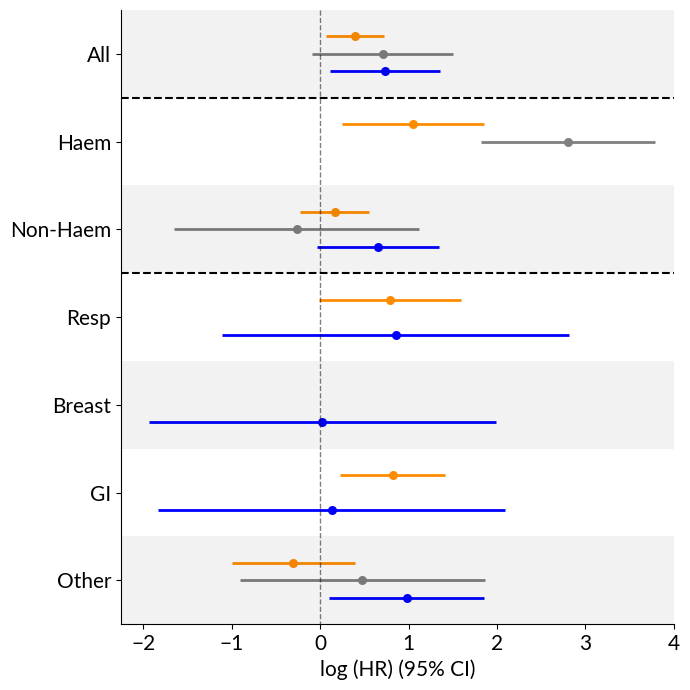

In [25]:
# same plot, new design
fig, ax = plt.subplots(1, 1, figsize=[7, 7])
sites_list = ['lymphoma_leukaemia', 'non_haem', 'respiratory', 'breast', 'gastrointestinal', 'other']
tick_labels_sites = ['All', 'Haem', 'Non-Haem', 'Resp', 'Breast', 'GI', 'Other']
variable_list = ['plp_unlikely_germline', 'plp_inconclusive', 'plp_likely_germline']
pos_list = [-0.20, 0, 0.20]

for j, model_name in enumerate(['CFN_ungerm', 'CFN_inc', 'CFN_germ']):
    df = get_results(all_models[model_name])
    variable = variable_list[j]
    ax.scatter(df.loc[variable]['coef'], pos_list[j], marker='o', c=colour_list[j], s=30)
    ax.errorbar(df.loc[variable]['coef'], pos_list[j],
                xerr=np.array([df.loc[variable]['lower_error'], df.loc[variable]['upper_error']]).reshape(2, 1),
                ls='none', zorder=-1, color=colour_list[j], capsize=0, lw=2)

for i, ctype in enumerate(sites_list):

    for j, model_name in enumerate([f'CFN_ungerm_{ctype}', f'CFN_inc_{ctype}', f'CFN_germ_{ctype}']):
        case_carriers = get_case_carriers(ctype, variable_list[j])
        if case_carriers > 0:
            df = get_results(all_models[model_name])
            variable = variable_list[j]
            ax.scatter(df.loc[variable]['coef'], i+pos_list[j]+1, marker='o', c=colour_list[j], s=30)
            ax.errorbar(df.loc[variable]['coef'], i+pos_list[j]+1,
                        xerr=np.array([df.loc[variable]['lower_error'], df.loc[variable]['upper_error']]).reshape(2, 1),
                        ls='none', zorder=-1, color=colour_list[j], capsize=0, lw=2)

ax.set_yticks(np.arange(len(sites_list)+1))
ax.set_yticklabels(tick_labels_sites, fontsize=15)
ax.axhspan(-0.5, 0.5, color='k', alpha=0.05, lw=0)
ax.axhspan(1.5, 2.5, color='k', alpha=0.05, lw=0)
ax.axhspan(3.5, 4.5, color='k', alpha=0.05, lw=0)
ax.axhspan(5.5, 6.5, color='k', alpha=0.05, lw=0)
#ax.hlines([1.5, 3.5, 4.5, 5.5, 6.5], -2.25, 4, color='k', lw=0.5)
ax.hlines([0.5, 2.5], -2.25, 4, color='k', ls='dashed')
ax.vlines(0, -0.5, len(sites_list)+0.5, color='k', ls='dashed', lw=1, alpha=0.5)
ax.set_ylim(-0.5, len(sites_list)+0.5)
ax.set_xlim(-2.25, 4)
ax.set_xlabel('log (HR) (95% CI)')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('TP53_manuscript/figures/cancer_associations_long_no_manual_assignment.pdf')

In [26]:
all_models.keys()

dict_keys(['NS_germ', 'NS_ungerm', 'NS_inc', 'CFN_germ', 'CFN_ungerm', 'CFN_inc', 'CFN_germ_respiratory', 'CFN_ungerm_respiratory', 'CFN_inc_respiratory', 'CFN_germ_gastrointestinal', 'CFN_ungerm_gastrointestinal', 'CFN_inc_gastrointestinal', 'CFN_germ_lymphoma_leukaemia', 'CFN_ungerm_lymphoma_leukaemia', 'CFN_inc_lymphoma_leukaemia', 'CFN_germ_breast', 'CFN_ungerm_breast', 'CFN_inc_breast', 'CFN_germ_other', 'CFN_ungerm_other', 'CFN_inc_other', 'CFN_germ_non_haem', 'CFN_ungerm_non_haem', 'CFN_inc_non_haem'])

In [27]:
df = get_results(all_models['CFN_ungerm_gastrointestinal'])
df['HR'] = np.exp(df['coef'])
df['HR_lower'] = np.exp(df['coef lower 95%'])
df['HR_upper'] = np.exp(df['coef upper 95%'])
df

,coef,coef lower 95%,coef upper 95%,lower_error,upper_error,p_value,HR,HR_lower,HR_upper
covariate,,,,,,,,,
Sex_male,0.448163,0.405604,0.490722,0.042559,0.042559,1.222957e-94,1.565434,1.500208,1.633495
Smoking_status_Ex,0.254557,0.209363,0.299752,0.045195,0.045195,2.465839e-28,1.289890,1.232892,1.349524
Smoking_status_Current,0.494897,0.428570,0.561224,0.066327,0.066327,1.968112e-48,1.640330,1.535061,1.752817
BMI_scaled,0.134693,0.114159,0.155228,0.020534,0.020534,7.944461e-38,1.144186,1.120930,1.167924
plp_unlikely_germline,0.819790,0.228405,1.411175,0.591385,0.591385,6.588822e-03,2.270023,1.256594,4.100770
iadmix_main_ancestry_v2_AFR,-0.232298,-0.461912,-0.002684,0.229614,0.229614,4.738168e-02,0.792710,0.630078,0.997320
iadmix_main_ancestry_v2_EAS,0.209549,-0.132895,0.551993,0.342444,0.342444,2.303943e-01,1.233121,0.875557,1.736710
iadmix_main_ancestry_v2_Mixed,-0.087655,-0.263077,0.087767,0.175422,0.175422,3.274020e-01,0.916077,0.768682,1.091733
iadmix_main_ancestry_v2_SAS,-0.538994,-0.771310,-0.306679,0.232316,0.232316,5.433829e-06,0.583335,0.462407,0.735887


In [28]:
data_cox[(data_cox.plp_unlikely_germline == 1) & (data_cox.respiratory_cancer_01 == 1)]

,ID_v0,Sex_v0,Ever.smoked_v0,Smoking_status,Smoking_level,pack_years,Body.mass.index..BMI._v0,Age.when.attended.assessment.centre_v0,Date.of.attending.assessment.centre_v0,first.diagnosed.cancer.age1,...,pathogenic_variant_over15,pathogenic_variant_under15,iadmix_main_ancestry_v2_AFR,iadmix_main_ancestry_v2_EAS,iadmix_main_ancestry_v2_EUR,iadmix_main_ancestry_v2_Mixed,iadmix_main_ancestry_v2_SAS,Sex_male,BMI_scaled,non_haem_cancer_01
4134,1049211,Male,True,Current,Current_heavy,44.0,19.6131,59,2009-08-19,68.8,...,0,1,False,False,True,False,False,True,-1.638638,1
12730,1152371,Male,True,Ex,Past_heavy,35.0,26.8989,69,2009-09-17,77.2,...,0,1,False,False,True,False,False,True,-0.108058,1
32555,1388991,Male,True,Current,Past_light,NaN,25.5185,65,2008-01-22,72.1,...,0,1,False,False,True,False,False,True,-0.398048,1
80811,1963937,Male,True,Ex,Past_light,NaN,30.3210,63,2007-11-23,70.3,...,0,1,False,False,True,False,False,True,0.610847,1
131582,2569361,Female,True,Current,Current_heavy,33.0,23.1247,63,2009-12-03,70.9,...,1,0,False,False,True,False,False,False,-0.900931,1
279298,4327811,Male,True,Ex,Past_heavy,5.0,35.7513,67,2009-04-01,72.6,...,0,1,False,False,True,False,False,True,1.751628,1


In [29]:
data_cox[(data_cox.plp_unlikely_germline == 1) & (data_cox.gastrointestinal_cancer_01 == 1)]

,ID_v0,Sex_v0,Ever.smoked_v0,Smoking_status,Smoking_level,pack_years,Body.mass.index..BMI._v0,Age.when.attended.assessment.centre_v0,Date.of.attending.assessment.centre_v0,first.diagnosed.cancer.age1,...,pathogenic_variant_over15,pathogenic_variant_under15,iadmix_main_ancestry_v2_AFR,iadmix_main_ancestry_v2_EAS,iadmix_main_ancestry_v2_EUR,iadmix_main_ancestry_v2_Mixed,iadmix_main_ancestry_v2_SAS,Sex_male,BMI_scaled,non_haem_cancer_01
13097,1156691,Male,True,Never,Past_very_light,0.0,26.1302,59,2008-03-19,65.4,...,0,1,False,False,True,False,False,True,-0.269544,1
112061,2336731,Male,True,Ex,Past_heavy,28.0,27.0367,70,2009-05-08,74.4,...,0,1,False,False,True,False,False,True,-0.079109,1
125493,2497039,Male,False,Never,Never,0.0,34.2173,67,2010-03-05,74.2,...,0,1,False,False,True,False,False,True,1.429370,1
152919,2822684,Male,True,Ex,Past_heavy,20.0,33.5986,60,2010-06-16,61.5,...,0,1,False,False,True,False,False,True,1.299395,1
171171,3041283,Male,True,Ex,Past_light,NaN,26.7484,69,2008-01-30,71.2,...,0,1,False,False,True,False,False,True,-0.139675,1
180040,3146957,Male,True,Ex,Past_heavy,41.0,28.4340,62,2009-11-23,70.2,...,0,1,False,False,True,False,False,True,0.214431,1
196145,3338176,Female,True,Ex,Past_heavy,15.5,20.8549,58,2008-04-03,72.2,...,0,1,False,False,True,False,False,False,-1.377764,1
222795,3655708,Female,False,Never,Never,0.0,22.5554,67,2009-11-30,69.1,...,1,0,False,False,True,False,False,False,-1.020528,1
296993,4538528,Male,False,Never,Never,0.0,28.1185,52,2009-06-02,59.4,...,0,1,False,False,True,False,False,True,0.148152,1
299085,4563380,Female,True,Current,Current_heavy,20.4,26.2080,66,2008-06-19,72.1,...,1,0,False,False,True,False,False,False,-0.253200,1


In [37]:
results_df = pd.DataFrame()
variable_dict = {'plp_unlikely_germline':'likely somatic',
                 'plp_inconclusive':'inconclusive',
                 'plp_likely_germline':'likely germline'}

column_order = ['outcome', 'variant_class', 'coef', 'coef lower 95%', 'coef upper 95%', 'p_value']
labels = ['outcome', 'variant_class', 'log_HR', 'lower_CI', 'upper_CI', 'p_value']
labels_dict = dict(zip(column_order, labels))

outcome_dict = {''}

# all-cancer results
for j, model_name in enumerate(['CFN_ungerm', 'CFN_inc', 'CFN_germ']):
    df = get_results(all_models[model_name])
    variable = variable_list[j]
    df['variant_class'] = variable_dict[variable]
    df['outcome'] = 'all cancer'
    df = df.reset_index().rename({'index':'covariate'})

    if results_df.empty:
        results_df = df[df.covariate == variable]
    else:
        results_df = pd.concat([results_df, df[df.covariate == variable]], axis=0)

for i, ctype in enumerate(sites_list):
    for j, model_name in enumerate([f'CFN_ungerm_{ctype}', f'CFN_inc_{ctype}', f'CFN_germ_{ctype}']):
        case_carriers = get_case_carriers(ctype, variable_list[j])  # sets `case_carriers`
        variable = variable_list[j]
        variant_class = variable_dict[variable]

        if case_carriers > 0:
            df = get_results(all_models[model_name])
            df['variant_class'] = variant_class
            df['outcome'] = ctype
            df = df.reset_index().rename({'index': 'covariate'})
            subset = df[df.covariate == variable]
        else:
            # Create a one-row DataFrame of NaNs with same columns
            row = pd.Series({col: np.nan for col in results_df.columns})
            row['covariate'] = variable
            row['variant_class'] = variant_class
            row['outcome'] = ctype
            subset = pd.DataFrame([row])

        results_df = pd.concat([results_df, subset], axis=0, ignore_index=True)
results_df = results_df[column_order].rename(columns=labels_dict).reset_index(drop=True)
results_df['outcome'] = results_df['outcome'].replace('lymphoma_leukaemia', 'haem')

results_df.to_csv('results/survival_analysis_reclassified.csv', index=False)

/var/folders/w8/g9qh0gj17pb80h64rgsdv5z40000gn/T/ipykernel_34764/2175817553.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'plp_likely_germline' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  row['covariate'] = variable
/var/folders/w8/g9qh0gj17pb80h64rgsdv5z40000gn/T/ipykernel_34764/2175817553.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'plp_inconclusive' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  row['covariate'] = variable
/var/folders/w8/g9qh0gj17pb80h64rgsdv5z40000gn/T/ipykernel_34764/2175817553.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'plp_unlikely_germline' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  row['c